---
title: "Insurance Claim Modeling: TabPFN vs. GLM"
description: "Model insurance pure premiums on zero-inflated claims data with TabPFN and compare against the classic actuarial GLM baselines"
icon: "car-burst"
cookbookTags:
  - regression
  - insurance
authors:
  - name: Philipp Singer
    linkedin: https://www.linkedin.com/in/philippsinger
    twitter: https://twitter.com/ph_singer
---

*Pricing risk on a heavily zero-inflated target — with zero feature engineering.*

Insurance claim data is *zero-inflated*: most policies never claim, and the
few that do produce heavily right-skewed amounts. The classic actuarial recipe is a **two-stage
GLM**: a frequency model (how often do claims happen?) times a severity model (how large are
they?). Getting a GLM to work takes real feature engineering — binning, one-hot encoding,
log-scaling, choosing link functions and a Tweedie power.

[TabPFN](https://github.com/PriorLabs/TabPFN) is a tabular foundation model that
learns in a single forward pass with **no per-dataset training and no preprocessing** — you hand
it the raw dataframe (mixed numeric + string columns, missing values and all). This notebook puts
single- and two-stage TabPFN models head-to-head with the matching scikit-learn GLM baselines on the standard French
Motor Third-Party Liability (freMTPL2) dataset, scored with common insurance metrics:
**Tweedie deviance / D²** (calibration) and the **exposure-weighted Gini** (ranking / lift).

Results: TabPFN **clearly beats the GLMs on risk ranking** (Gini 0.321 vs 0.306) with *zero*
feature engineering, and after a simple portfolio-level rebalancing — which log-link GLMs perform
implicitly on their training data — reaches **comparable calibration** (Tweedie deviance within ~1%).

> **Requirements.** A CUDA GPU (H100-class recommended for the full data). The first TabPFN call
> downloads the model weights. Baselines, dataset explanations and metrics follow scikit-learn's
> [Tweedie regression on insurance claims](https://scikit-learn.org/stable/auto_examples/linear_model/plot_tweedie_regression_insurance_claims.html) example.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (
    KBinsDiscretizer, OneHotEncoder, StandardScaler, FunctionTransformer,
)
from sklearn.linear_model import PoissonRegressor, GammaRegressor, TweedieRegressor
from sklearn.metrics import mean_tweedie_deviance, d2_tweedie_score, auc

from tabpfn import TabPFNClassifier, TabPFNRegressor

# Benign numeric overflow in TabPFN's inverse target transform (expm1 on the far
# tail of the output distribution's support); results are unaffected.
warnings.filterwarnings("ignore", message="overflow encountered in exp")

RANDOM_STATE = 0
N_ESTIMATORS = 8
FEATURES = ["VehAge", "DrivAge", "VehBrand", "VehPower", "VehGas",
            "Region", "Area", "BonusMalus", "Density"]

## The data

In this dataset, each sample corresponds to an insurance policy, i.e., a contract within an insurance company and an individual (policyholder). Available features include driver age, vehicle age, vehicle power, etc. A claim is the request made by a policyholder to the insurer to compensate for a loss covered by the insurance. The claim amount is the amount of money that the insurer must pay. The exposure is the duration of the insurance coverage of a given policy, in years.

Here our goal is to predict the expected value, i.e., the mean, of the total claim amount per exposure unit also referred to as the pure premium.

There are usually two common ways of modeling this:

- Model the number of claims, and the average claim amount per claim, also known as severity, and multiply the predictions of both in order to get the total claim amount.
- Model the total claim amount per exposure directly

`freMTPL2freq` holds one row per policy (risk features, claim count `ClaimNb`, and `Exposure` =
fraction of a year observed). `freMTPL2sev` holds the individual claim amounts. We aggregate claim
amounts per policy and join, policies with no claim get `ClaimAmount = 0`.

We apply the same light cleaning as the scikit-learn example (cap extreme values, make `ClaimNb`
consistent with `ClaimAmount`) and derive the modeling targets:
`Frequency = ClaimNb / Exposure`, `AvgClaimAmount = ClaimAmount / ClaimNb`, and
`PurePremium = ClaimAmount / Exposure` (the expected cost per unit exposure, what we ultimately
predict).

Note the feature columns: `VehBrand`, `VehGas`, `Region`, `Area` are **strings**; the rest are numeric on very different scales. A GLM cannot consume this directly, TabPFN can.

In [2]:
freq = fetch_openml(data_id=41214, as_frame=True).frame   # policies: features + ClaimNb + Exposure
sev = fetch_openml(data_id=41215, as_frame=True).frame     # individual claim amounts

df = freq.copy()
df["ClaimAmount"] = df["IDpol"].map(sev.groupby("IDpol")["ClaimAmount"].sum()).fillna(0.0)

# Standard cleaning.
df["ClaimNb"] = df["ClaimNb"].clip(upper=4)
df["Exposure"] = df["Exposure"].clip(upper=1)
df["ClaimAmount"] = df["ClaimAmount"].clip(upper=200_000)
df.loc[(df["ClaimAmount"] == 0) & (df["ClaimNb"] >= 1), "ClaimNb"] = 0

# Insurance companies are interested in modeling the Pure Premium, that is
# the expected total claim amount per unit of exposure for each policyholder
# in their portfolio:
df["PurePremium"] = df["ClaimAmount"] / df["Exposure"]

# This can be indirectly approximated by a 2-step modeling: the product of the
# Frequency times the average claim amount per claim:
df["Frequency"] = df["ClaimNb"] / df["Exposure"]
df["AvgClaimAmount"] = df["ClaimAmount"] / np.fmax(df["ClaimNb"], 1)

zero = (df["ClaimAmount"] == 0).mean()
print(f"{len(df):,} policies | {100 * zero:.1f}% have ZERO claim amount | "
      f"{(df.ClaimAmount > 0).sum():,} claims")
df[FEATURES + ["Exposure", "ClaimNb", "ClaimAmount", "PurePremium", "Frequency", "AvgClaimAmount"]].sort_values("ClaimAmount", ascending=False).head()

678,013 policies | 96.3% have ZERO claim amount | 24,944 claims


,VehAge,DrivAge,VehBrand,VehPower,VehGas,Region,Area,BonusMalus,Density,Exposure,ClaimNb,ClaimAmount,PurePremium,Frequency,AvgClaimAmount
298185,5,31,B2,7,'Diesel',R24,B,51,60,0.42,1,200000.0,4.761905e+05,2.380952,200000.0
135927,12,27,B2,4,'Regular',R24,C,90,319,1.00,1,200000.0,2.000000e+05,1.000000,200000.0
75668,3,46,B1,6,'Diesel',R24,A,50,10,0.75,1,200000.0,2.666667e+05,1.333333,200000.0
231941,13,21,B1,4,'Diesel',R24,A,140,37,0.16,2,200000.0,1.250000e+06,12.500000,100000.0
568614,9,72,B1,5,'Diesel',R24,C,50,405,0.36,1,200000.0,5.555556e+05,2.777778,200000.0


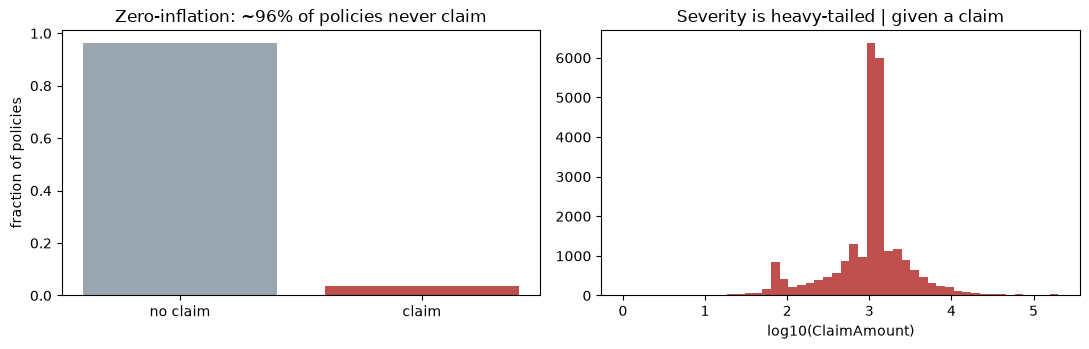

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(["no claim", "claim"],
          [(df.ClaimAmount == 0).mean(), (df.ClaimAmount > 0).mean()],
          color=["#9aa7b0", "#c0504d"])
ax[0].set_ylabel("fraction of policies")
ax[0].set_title("Zero-inflation: ~96% of policies never claim")

pos = df.loc[df.ClaimAmount > 0, "ClaimAmount"]
ax[1].hist(np.log10(pos), bins=50, color="#c0504d")
ax[1].set_xlabel("log10(ClaimAmount)")
ax[1].set_title("Severity is heavy-tailed | given a claim")
plt.tight_layout()
plt.show()

In [4]:
df_train, df_test = train_test_split(df, test_size=0.25, random_state=RANDOM_STATE)
pp_true = df_test["PurePremium"].to_numpy()
weight = df_test["Exposure"].to_numpy()          # exposure-weighting for the metrics
print(f"train {len(df_train):,} | test {len(df_test):,}")

train 508,509 | test 169,504


In [5]:
def gini_exposure(y_true, y_pred, exposure):
    order = np.argsort(y_pred)                     # ascending: safest -> riskiest
    exp = np.asarray(exposure)[order]
    claim = np.asarray(y_true)[order] * exp
    cum_claim = np.cumsum(claim) / claim.sum()
    cum_exp = np.cumsum(exp) / exp.sum()
    return 1 - 2 * auc(cum_exp, cum_claim)

# We deliberately do NOT report MAE (degenerate on a 96%-zero target: it rewards
# predicting near-zero for everyone) or RMSE (dominated by a few catastrophic
# claims -- it is identical to 4 digits across all models here).
def scores(pred):
    pred = np.clip(pred, 1e-6, None)               # Tweedie deviance needs strictly positive
    return {
        "D2 (Tweedie 1.9)  up": d2_tweedie_score(pp_true, pred, sample_weight=weight, power=1.9),
        "Tweedie dev 1.9  down": mean_tweedie_deviance(pp_true, pred, sample_weight=weight, power=1.9),
        "Tweedie dev 1.5  down": mean_tweedie_deviance(pp_true, pred, sample_weight=weight, power=1.5),
        "Gini (exposure)  up": gini_exposure(pp_true, pred, weight),
    }

## GLM baselines

GLMs are linear models, so every feature has to be hand-engineered into a numeric design matrix:
bin the skewed numerics, one-hot the categoricals, log-and-scale the heavy-tailed one. On top of
that shared design matrix we fit the two classic recipes for the pure premium — first a
**single-stage** direct Tweedie model, then the **two-stage** frequency × severity product.

### Single-stage GLM: direct Tweedie on pure premium

The simplest recipe: one `TweedieRegressor` fit straight on `PurePremium`, weighted by `Exposure`. No occurrence/severity
split — a single model for the whole target. We set `power=1.9` following the scikit-learn tutorial; in practice this hyperparameter would be optimized on a grid.

In [6]:
def make_glm_preprocessor():
    # A fresh ColumnTransformer per model (so fitting one does not overwrite another).
    log_scale = make_pipeline(FunctionTransformer(np.log, validate=False), StandardScaler())
    return ColumnTransformer([
        ("binned", KBinsDiscretizer(n_bins=10, random_state=RANDOM_STATE), ["VehAge", "DrivAge"]),
        ("onehot", OneHotEncoder(handle_unknown="ignore"),
         ["VehBrand", "VehPower", "VehGas", "Region", "Area"]),
        ("passthrough", "passthrough", ["BonusMalus"]),
        ("log_scaled", log_scale, ["Density"]),
    ], remainder="drop")

Xtr = df_train[FEATURES]
n_design = make_glm_preprocessor().fit_transform(Xtr).shape[1]
print(f"GLM design matrix: {n_design} engineered columns from {len(FEATURES)} raw features")

# Single-stage: a direct Tweedie model on the pure premium, weighted by exposure.
glm_tweedie = Pipeline([("prep", make_glm_preprocessor()),
                        ("reg", TweedieRegressor(power=1.9, alpha=0.1, max_iter=1000))])
glm_tweedie.fit(Xtr, df_train["PurePremium"], reg__sample_weight=df_train["Exposure"])
pp_glm_tweedie = glm_tweedie.predict(df_test[FEATURES])

GLM design matrix: 75 engineered columns from 9 raw features


In [7]:
scores(pp_glm_tweedie)

{'D2 (Tweedie 1.9)  up': 0.013734740755400598,
 'Tweedie dev 1.9  down': 33.87828097427191,
 'Tweedie dev 1.5  down': 76.40871982023906,
 'Gini (exposure)  up': 0.2883310924949033}

### Two-stage GLM: frequency × severity

The classic actuarial product: a **Poisson** frequency model (how often claims happen, weighted by
exposure) times a **Gamma** severity model (average amount per claim, fit on claim rows only and
weighted by claim count). Their product is the expected cost per unit exposure. Again, we follow the scikit learn tutorial, and set the hyperparameters accordingly.

In [8]:
# Stage 1 - frequency: Poisson, weighted by exposure.
glm_freq = Pipeline([("prep", make_glm_preprocessor()),
                     ("reg", PoissonRegressor(alpha=1e-4, max_iter=500))])
glm_freq.fit(Xtr, df_train["Frequency"], reg__sample_weight=df_train["Exposure"])

# Stage 2 - severity: Gamma on claim rows only, weighted by claim count.
claim = df_train["ClaimAmount"] > 0
glm_sev = Pipeline([("prep", make_glm_preprocessor()),
                    ("reg", GammaRegressor(alpha=10.0, max_iter=500))])
glm_sev.fit(Xtr[claim.values], df_train.loc[claim, "AvgClaimAmount"],
            reg__sample_weight=df_train.loc[claim, "ClaimNb"])

pp_glm_product = glm_freq.predict(df_test[FEATURES]) * glm_sev.predict(df_test[FEATURES])

In [9]:
scores(pp_glm_product)

{'D2 (Tweedie 1.9)  up': 0.014582963672741034,
 'Tweedie dev 1.9  down': 33.84914445744429,
 'Tweedie dev 1.5  down': 76.16497654067228,
 'Gini (exposure)  up': 0.3057401637188083}

## TabPFN

Now the same two recipes with TabPFN, but we feed the **raw dataframe** — strings, integers, and
floats together, no encoding, no scaling, no binning, no per-dataset hyperparameter tuning. The one
modeling choice we make is a log target transform (below), the natural choice for heavy-tailed
monetary amounts.

Two adaptations because TabPFN has no `sample_weight`/offset (which the GLMs use for exposure):

- **Exposure becomes an ordinary input feature**, and we model the *bounded* `ClaimAmount` rather
  than the exploding per-exposure target `PurePremium` (amount / tiny-exposure blows up the tail).
- **The pure premium is read off with a counterfactual query**: every test policy is predicted at a
  full year of exposure (`Exposure = 1.0`), so the prediction is already the expected cost per unit
  exposure — no division needed.

### Single-stage TabPFN: regress the claim amount directly

The analog of the single-stage GLM: drop the occurrence/severity split entirely and hand a single
`TabPFNRegressor` the raw, 96%-zero `ClaimAmount`, then query at full exposure. The simplest possible
recipe, one `.fit()` — the scores below show what the target transform and the two-stage structure buy.

A TabPFN bonus: `predict(..., output_type="full")` returns the **full predictive distribution**
(mean, median, quantiles), not just a point estimate — we use the mean, the estimator of the
expected cost.

In [10]:
tab_features = FEATURES + ["Exposure"]
X_tr = df_train[tab_features]

reg_single = TabPFNRegressor(n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True)
reg_single.fit(X_tr, df_train["ClaimAmount"])

# Counterfactual query: what would this policy cost over a FULL year?
X_te_unit = df_test[tab_features].copy()
X_te_unit["Exposure"] = 1.0

# in TabPFN we can get the full distribution
pp_tabpfn_single = reg_single.predict(X_te_unit, output_type="full")

In [11]:
pp_tabpfn_single.keys()

dict_keys(['mean', 'median', 'mode', 'quantiles', 'criterion', 'logits'])

In [12]:
scores(pp_tabpfn_single["mean"])

{'D2 (Tweedie 1.9)  up': -675.4243683338696,
 'Tweedie dev 1.9  down': 23235.22459445761,
 'Tweedie dev 1.5  down': 331.3394097941406,
 'Gini (exposure)  up': 0.3146402565691172}

In [13]:
# The default target preprocessing struggles with a 96%-zero, heavy-tailed target: the
# calibration above is far off. Setting a log target transform — the standard choice for
# monetary amounts (same reason the GLMs use log links) — fixes most of it.
reg_single = TabPFNRegressor(n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True,
                             inference_config={"REGRESSION_Y_PREPROCESS_TRANSFORMS": ("1_plus_log",)})
reg_single.fit(X_tr, df_train["ClaimAmount"])
pp_tabpfn_single = reg_single.predict(X_te_unit, output_type="full")

In [14]:
scores(pp_tabpfn_single["mean"])

{'D2 (Tweedie 1.9)  up': -0.15469641202578832,
 'Tweedie dev 1.9  down': 39.66390291041523,
 'Tweedie dev 1.5  down': 99.05849234181795,
 'Gini (exposure)  up': 0.3117645729694489}

### Two-stage TabPFN: occurrence × severity

The analog of the two-stage GLM, but with no frequency/Gamma machinery:

- **Stage 1 — occurrence:** `TabPFNClassifier` for `P(claim > 0)`.
- **Stage 2 — severity:** `TabPFNRegressor` for `E[ClaimAmount | claim > 0]`, trained on claim rows only.

Expected cost is `P(claim) × severity`. Both stages are queried at `Exposure = 1.0`, so the
product is already the pure premium.

In [15]:
# Counterfactual test set: every policy evaluated at a FULL year of exposure
X_te_unit = df_test[tab_features].copy()
X_te_unit["Exposure"] = 1.0

# Stage 1: occurrence  P(claim > 0 | full year)
clf = TabPFNClassifier(n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True)
clf.fit(X_tr, (df_train["ClaimAmount"] > 0).astype(int))
p_claim = clf.predict_proba(X_te_unit)[:, list(clf.classes_).index(1)]

In [16]:
# Stage 2: severity  E[ClaimAmount | claim > 0]
pos = (df_train["ClaimAmount"] > 0).values
reg = TabPFNRegressor(n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True, inference_config={"REGRESSION_Y_PREPROCESS_TRANSFORMS": ("1_plus_log",)})
reg.fit(X_tr[pos], df_train.loc[pos, "ClaimAmount"])
severity = reg.predict(X_te_unit, output_type="full")

In [17]:
pp_tabpfn = p_claim * severity["mean"]
scores(pp_tabpfn)

{'D2 (Tweedie 1.9)  up': -0.02080075361396938,
 'Tweedie dev 1.9  down': 35.0645776331718,
 'Tweedie dev 1.5  down': 81.90677245047317,
 'Gini (exposure)  up': 0.32079809781930857}

### Recalibrating the two-stage level

The two-stage TabPFN ranks well but under-predicts the premium **level** (hence the negative D²): both stages are biased low — the classifier's probabilities are shrunk toward the base rate, and the `1_plus_log` severity mean under-weights the heavy tail. The GLMs don't have this problem: a log-link GLM with an intercept is automatically *balanced* on its training portfolio. We give TabPFN the same single degree of freedom — a **constant factor** estimated on a calibration slice carved out of the training set (never test).

We compute two views of it:

- **Per-stage factors** (diagnostics): how far off is each stage's mean on its own?
- **Direct product-level factor** (applied): actual cal claim cost ÷ what the deployed pipeline would have charged the cal policies. This targets exactly the exposure-weighted product that the balance measures, so the p×s correlation across policies and the claimant-selection effect are inside the estimate — the per-stage product misses both and undershoots.

A constant factor is Gini-safe: `c·(p×s)` orders policies exactly like `p×s`, so this fixes calibration without touching the ranking result.

One TabPFN-specific catch: rows that are *in context* are effectively memorized, so the models used to score the calibration slice must be re-fit without it.

In [18]:
# Calibration slice carved out of TRAIN (never test). TabPFN effectively memorizes its
# in-context rows, so the models used to score the cal slice are re-fit WITHOUT it.
df_fit, df_cal = train_test_split(df_train, test_size=0.1, random_state=RANDOM_STATE)
X_fit = df_fit[tab_features]
X_cal_unit = df_cal[tab_features].copy()
X_cal_unit["Exposure"] = 1.0
has_claim_cal = (df_cal["ClaimAmount"] > 0).to_numpy()

# Stage 1 on df_fit: P(claim > 0 | full year) for every cal policy
clf_cal = TabPFNClassifier(n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True)
clf_cal.fit(X_fit, (df_fit["ClaimAmount"] > 0).astype(int))
p_claim_cal = clf_cal.predict_proba(X_cal_unit)[:, list(clf_cal.classes_).index(1)]

# Stage 2 on df_fit claim rows: severity for EVERY cal policy (not just claimants) — the
# product-level factor must weight severity exactly the way the deployed pipeline does.
pos_fit = (df_fit["ClaimAmount"] > 0).values
reg_cal = TabPFNRegressor(n_estimators=N_ESTIMATORS, ignore_pretraining_limits=True,
                          inference_config={"REGRESSION_Y_PREPROCESS_TRANSFORMS": ("1_plus_log",)})
reg_cal.fit(X_fit[pos_fit], df_fit.loc[pos_fit, "ClaimAmount"])
severity_cal = reg_cal.predict(X_cal_unit, output_type="full")["mean"]

In [19]:
# Per-stage factors — DIAGNOSTICS only: which stage is biased, and by how much?
occ_factor = (has_claim_cal.sum() / df_cal["Exposure"].sum()) / p_claim_cal.mean()
sev_factor = (df_cal.loc[has_claim_cal, "ClaimAmount"].mean()
              / severity_cal[has_claim_cal].mean())

# Direct product-level factor — APPLIED: actual cal cost / what the deployed pipeline
# would have charged the cal policies. Rescales the product itself, so the p×s
# correlation, claimant selection, and exposure weighting are all inside the estimate.
# (The analogue of the balancing a log-link GLM's intercept performs on train.)
pp_cal = p_claim_cal * severity_cal
c_direct = df_cal["ClaimAmount"].sum() / (pp_cal * df_cal["Exposure"]).sum()

pp_tabpfn_recal = c_direct * pp_tabpfn   # constant scaling: Gini unchanged

bal_before = (pp_tabpfn * weight).sum() / (pp_true * weight).sum()
bal_after = (pp_tabpfn_recal * weight).sum() / (pp_true * weight).sum()
print(f"diagnostics: occurrence {occ_factor:.3f} x severity {sev_factor:.3f} "
      f"= {occ_factor * sev_factor:.3f}")
print(f"applied:     direct product-level factor {c_direct:.3f} "
      f"(gap vs per-stage product = p×s correlation + claimant selection)")
print(f"test balance (pred/actual): {bal_before:.3f} -> {bal_after:.3f}")
scores(pp_tabpfn_recal)

diagnostics: occurrence 1.313 x severity 1.159 = 1.522
applied:     direct product-level factor 1.634 (gap vs per-stage product = p×s correlation + claimant selection)
test balance (pred/actual): 0.585 -> 0.956


{'D2 (Tweedie 1.9)  up': 0.009552132415574066,
 'Tweedie dev 1.9  down': 34.02195386471774,
 'Tweedie dev 1.5  down': 77.04185006022182,
 'Gini (exposure)  up': 0.32079809781930857}

## Results

All models side by side, then three complementary views: the **Lorenz curves** (ranking), a
**decile calibration chart** (is the premium level right segment by segment?), and a **double
lift chart** (head-to-head: where the two champions disagree, who is right?).

**Lorenz curves**: for each model, policies are sorted safest → riskiest by predicted premium, and
we plot the cumulative share of *actual* claim cost against the cumulative share of exposure.
Lower / more bowed = better risk separation; the Gini in the legend is (twice) the area between
each curve and the diagonal.

Two reference lines frame the plot: **random** (the diagonal — no information) and the **oracle**
(sorted by realized losses — Gini 0.984, not 1.0, because the claim-bearing policies still occupy
~4% of the exposure axis). No expected-risk model can approach the oracle: realized claims are
mostly luck; a model can only rank who is riskier *on average*. Note the recalibrated two-stage
curve overlays the uncalibrated one exactly — constant rescaling fixes the level without moving a
single policy in the ranking.

In [20]:
table = pd.DataFrame({
    "GLM Tweedie(1.9)": scores(pp_glm_tweedie),
    "GLM Poisson x Gamma": scores(pp_glm_product),
    "TabPFN single-stage": scores(pp_tabpfn_single["mean"]),
    "TabPFN two-stage": scores(pp_tabpfn),
    "TabPFN two-stage recal.": scores(pp_tabpfn_recal),
})
table.round(4)

,GLM Tweedie(1.9),GLM Poisson x Gamma,TabPFN single-stage,TabPFN two-stage,TabPFN two-stage recal.
D2 (Tweedie 1.9) up,0.0137,0.0146,-0.1547,-0.0208,0.0096
Tweedie dev 1.9 down,33.8783,33.8491,39.6639,35.0646,34.0220
Tweedie dev 1.5 down,76.4087,76.1650,99.0585,81.9068,77.0419
Gini (exposure) up,0.2883,0.3057,0.3118,0.3208,0.3208


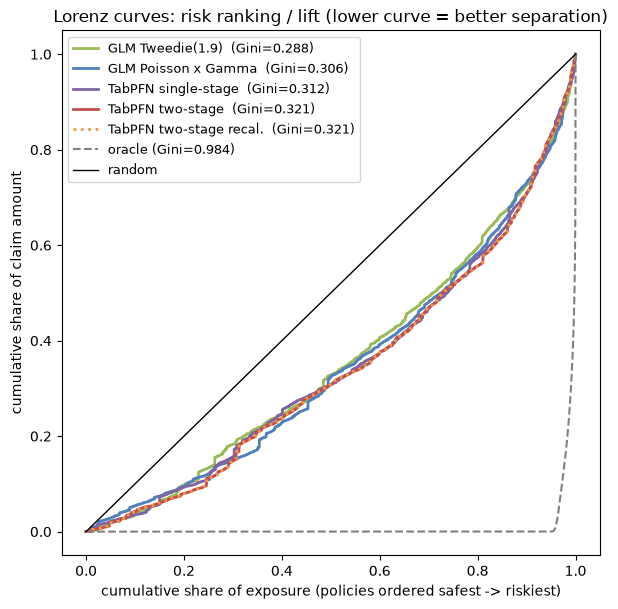

In [21]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))
curves = [
    ("GLM Tweedie(1.9)", pp_glm_tweedie, "#9bbb59", "-"),
    ("GLM Poisson x Gamma", pp_glm_product, "#4f81bd", "-"),
    ("TabPFN single-stage", pp_tabpfn_single["mean"], "#8064a2", "-"),
    ("TabPFN two-stage", pp_tabpfn, "#c0504d", "-"),
    # Constant rescaling preserves the ordering, so this overlays two-stage exactly
    ("TabPFN two-stage recal.", pp_tabpfn_recal, "#f79646", ":"),
]
for label, pred, color, ls in curves:
    order = np.argsort(pred)
    exp = weight[order]
    claim = pp_true[order] * exp
    cx = np.insert(np.cumsum(exp) / exp.sum(), 0, 0)
    cy = np.insert(np.cumsum(claim) / claim.sum(), 0, 0)
    ax.plot(cx, cy, color=color, lw=2, ls=ls,
            label=f"{label}  (Gini={gini_exposure(pp_true, pred, weight):.3f})")

order = np.argsort(pp_true)                          # oracle
exp = weight[order]; claim = pp_true[order] * exp
ax.plot(np.insert(np.cumsum(exp) / exp.sum(), 0, 0),
        np.insert(np.cumsum(claim) / claim.sum(), 0, 0),
        "--", color="grey", label=f"oracle (Gini={gini_exposure(pp_true, pp_true, weight):.3f})")
ax.plot([0, 1], [0, 1], color="black", lw=1, label="random")

ax.set_xlabel("cumulative share of exposure (policies ordered safest -> riskiest)")
ax.set_ylabel("cumulative share of claim amount")
ax.set_title("Lorenz curves: risk ranking / lift (lower curve = better separation)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## Takeaways

- **TabPFN wins on ranking.** The two-stage TabPFN reaches **Gini 0.321 vs 0.306** for the best
  GLM — meaningfully better risk separation, which is what drives pricing and segmentation — from
  the raw 9-feature dataframe.
- **Zero feature engineering.** The GLM needed a hand-built design matrix (binning, one-hot,
  log-scaling — 75 engineered columns and several modeling choices). TabPFN consumed the raw
  dataframe — strings and all — with a plain `.fit()` / `.predict()`.
- **Calibration is comparable after rebalancing.** Out of the box TabPFN under-predicts the premium
  *level*: it has no exposure weights/offsets (a structural advantage the GLMs keep), and the
  log-transformed severity mean under-weights the heavy tail. A single portfolio-level factor
  estimated on a training calibration slice — the same balancing a log-link GLM's intercept
  performs implicitly — restores the level (balance 0.59 → 0.96) and brings the Tweedie deviance
  within 0.5% of the GLMs (34.02 vs 33.85), while provably leaving the Gini untouched (see the
  overlapping Lorenz curves). Worth noting: the calibration metric is the GLM's own training
  objective, exposure weights included — deviance parity from a model that never optimized it is
  arguably the stronger result.
- **The two-stage structure matters for TabPFN too.** Modeling occurrence and severity separately
  is better calibrated than a single regressor on the raw zero-inflated amount, mirroring the
  classic actuarial decomposition.
- **Right metric, right conclusion.** On zero-inflated cost, judge *calibration* with Tweedie
  deviance/D² and the decile chart, *ranking* with the exposure-weighted Gini, and settle
  head-to-head comparisons with the double lift chart. We deliberately do not report MAE
  (degenerate: it rewards predicting near-zero for everyone) or RMSE (dominated by a few
  catastrophic claims — identical to 4 digits across all models here).